In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import brainmass
import brainstate
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Building Multi-Region Networks

This tutorial covers creating and simulating large-scale brain networks with multiple regions.

:::{note}
Every code block on this page is executed as part of the documentation build, so
the snippets run against the current API. Because real connectomes ship as
external data files, the structural connectivity here is **synthesised inline**
(a fixed-seed random matrix) -- swap in `np.load('your_SC.npy')` to use your own.
For a complete, copy-pasteable coupling walkthrough see {doc}`/getting_started/quickstart`.
:::

## Basic Network Setup

A brain network consists of:

1. **Nodes**: Neural mass models representing brain regions
2. **Edges**: Structural connectivity between regions
3. **Coupling**: Mechanism for inter-regional communication

### Simple Network Example

{class}`~brainmass.Network` wires a node model into a delay-coupled whole-brain
network: it zeros the connectivity diagonal, turns a distance matrix into
conduction delays (`distance / speed`), prefetches each region's delayed state,
and feeds the {class}`~brainmass.DiffusiveCoupling` current back into the node.
The {class}`~brainmass.Simulator` then drives it -- the whole loop that used to be
hand-written collapses to a few lines:

In [2]:
import brainmass
import braintools
import jax.numpy as jnp
import brainunit as u
import brainstate

brainstate.environ.set(dt=0.1 * u.ms)
N_regions = 10

# 1. Node dynamics for all regions
nodes = brainmass.HopfStep(
    in_size=N_regions,
    w=0.2,   # intrinsic angular frequency (dimensionless normal-form parameter)
    a=0.1,
)

# 2. Structural connectivity and inter-region distances (synthetic)
W = jnp.ones((N_regions, N_regions)) * 0.05         # Network zeros the diagonal
distance = jnp.ones((N_regions, N_regions)) * 2.0   # mm

# 3. Build the delay-coupled network (couple the ``x`` state)
net = brainmass.Network(
    nodes,
    conn=W,
    distance=distance,
    speed=2.0,                # mm/ms -> 1 ms delays
    coupled_var='x',
    k=0.2,
    delay_init=braintools.init.Constant(0.0),
)

# 4. Drive it with the simulator (init + loop + collect handled for you)
sim = brainmass.Simulator(net, dt=0.1 * u.ms)
res = sim.run(100.0 * u.ms, monitors=lambda m: m.node.x.value)
network_activity = res['output']   # shape (time steps, regions)
print(network_activity.shape)      # (1000, 10)

(1000, 10)


## Structural Connectivity

### Loading from DTI

In [3]:
import numpy as np
import jax.numpy as jnp

# In practice you load structural connectivity from DTI tractography
# (.npy, .mat, .txt). Here we synthesise an (N, N) matrix with a fixed seed
# so the tutorial is self-contained:
#     SC = jnp.asarray(np.load('structural_connectivity.npy'))
N = 90
SC = np.asarray(np.random.RandomState(0).rand(N, N) * 0.1)
np.fill_diagonal(SC, 0.0)          # no self-connections
SC = jnp.asarray(SC)               # shape (N, N)

# Typically: SC[i, j] = fiber density from j -> i

# Normalize (common preprocessing). Column normalization:
SC_col = SC / SC.sum(axis=0, keepdims=True)

# Or row normalization:
SC_row = SC / SC.sum(axis=1, keepdims=True)

print(SC.shape, float(SC_row.sum(axis=1)[0]))   # rows sum to 1.0

(90, 90) 1.0


### Creating Synthetic Networks

**Random Network:**

In [4]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(0)
N = 90

# Random weights, no self-connections
W_random = jax.random.uniform(key, (N, N)) * 0.1
W_random = W_random.at[jnp.diag_indices(N)].set(0.)

print(W_random.shape, float(jnp.diag(W_random).sum()))   # diagonal is zero

(90, 90) 0.0


**Small-World Network:**

In [5]:
import numpy as np
import jax.numpy as jnp

# Simplified small-world (Watts-Strogatz: ring lattice + random shortcuts)
N = 90
k = 4          # each node connects to its k nearest neighbours
p_rewire = 0.1  # probability of rewiring each lattice edge

rng = np.random.RandomState(42)
W = np.zeros((N, N))

# Ring lattice: connect each node to k//2 neighbours on each side
for j in range(1, k // 2 + 1):
    idx = np.arange(N)
    W[idx, (idx + j) % N] = 0.1
    W[idx, (idx - j) % N] = 0.1

# Random rewiring of existing edges to create shortcuts
for i in range(N):
    for j in np.where(W[i] > 0)[0]:
        if rng.rand() < p_rewire:
            W[i, j] = 0.0
            new = rng.randint(N)
            while new == i or W[i, new] > 0:
                new = rng.randint(N)
            W[i, new] = 0.1

W_small_world = jnp.asarray(W)
print(W_small_world.shape, int((W_small_world > 0).sum()))   # ~N*k edges

(90, 90) 360


**Hub Network:**

In [6]:
import jax.numpy as jnp

N = 90
N_hubs = 5

W = jnp.zeros((N, N))

# Hubs connect to all regions (both directions)
W = W.at[:N_hubs, :].set(0.2)
W = W.at[:, :N_hubs].set(0.2)

# Remove self-connections
W = W.at[jnp.diag_indices(N)].set(0.)
W_hub = W

print(W_hub.shape, float(W_hub[0].sum()))   # hub row is densely connected

(90, 90) 17.79999542236328


## Realistic Brain Networks

### Using Anatomical Atlases

In [7]:
import brainmass
import braintools
import numpy as np
import jax.numpy as jnp
import brainunit as u

brainstate.environ.set(dt=0.1 * u.ms)

# Example: AAL90 atlas (90 regions). In practice:
#     SC_AAL90 = jnp.asarray(np.load('AAL90_SC.npy'))  # from DTI
N_AAL90 = 90
SC_AAL90 = np.asarray(np.random.RandomState(0).rand(N_AAL90, N_AAL90) * 0.1)
np.fill_diagonal(SC_AAL90, 0.0)
SC_AAL90 = jnp.asarray(SC_AAL90)

# Build a diffusively-coupled Wilson-Cowan network over the atlas.
# ``Network`` owns the prefetch/coupling wiring described in the quickstart.
nodes = brainmass.WilsonCowanStep(in_size=N_AAL90)
net = brainmass.Network(
    nodes,
    conn=SC_AAL90,
    coupled_var='rE',
    k=0.1,
    delay_init=braintools.init.Constant(0.0),
)
print(net.n_node, type(net.coupling).__name__)   # 90 DiffusiveCoupling

90 DiffusiveCoupling


**Common Atlases:**

- AAL (Automated Anatomical Labeling): 90/116 regions
- Desikan-Killiany: 68 cortical regions
- Destrieux: 148 cortical regions
- Schaefer: 100/200/400/etc. parcels

### Distance-Dependent Delays

For large-scale networks, account for axonal conduction delays:

In [8]:
import brainmass
import braintools
import numpy as np
import jax.numpy as jnp
import brainunit as u

brainstate.environ.set(dt=0.1 * u.ms)
N_regions = 90

# Inter-region distances (mm). In practice: jnp.load('region_distances.npy')
distances = np.asarray(np.random.RandomState(1).rand(N_regions, N_regions) * 50.0)
np.fill_diagonal(distances, 0.0)

# Conduction speed (mm/ms; ~ m/s). Delays follow distance / speed.
speed = 6.0
delays_ms = distances / speed                    # continuous delays (ms)
print('max delay:', float(delays_ms.max()), 'ms')

# ``Network`` turns the distance matrix into conduction delays internally
# (distance / speed) and manages the delayed-state buffers for you -- no
# hand-rolled circular buffer required.
nodes = brainmass.HopfStep(in_size=N_regions, a=0.1, w=0.2)
SC = np.asarray(np.random.RandomState(2).rand(N_regions, N_regions) * 0.1)
np.fill_diagonal(SC, 0.0)
net = brainmass.Network(
    nodes,
    conn=jnp.asarray(SC),
    distance=jnp.asarray(distances),
    speed=speed,
    coupled_var='x',
    k=0.1,
    delay_init=braintools.init.Constant(0.0),
)
print('delay-coupled network with', net.n_node, 'regions')

max delay: 8.33229822978552 ms
delay-coupled network with 90 regions


## Heterogeneous Networks

### Different Models per Region

In [9]:
import brainmass
import brainstate
import brainunit as u
import numpy as np
import jax.numpy as jnp

brainstate.environ.set(dt=0.1 * u.ms)

# Thalamus: fast Hopf oscillators
N_thal = 10
thalamus = brainmass.HopfStep(
    in_size=N_thal,
    a=0.25,
    w=0.3,   # faster intrinsic frequency than the cortical subsystem
)

# Cortex: excitatory-inhibitory Wilson-Cowan dynamics
N_cort = 80
cortex = brainmass.WilsonCowanStep(in_size=N_cort)

# Inter-subsystem connectivity (fixed seed)
W_thal_cort = jnp.asarray(np.random.RandomState(0).rand(N_cort, N_thal) * 0.1)  # thalamus -> cortex
W_cort_thal = jnp.asarray(np.random.RandomState(1).rand(N_thal, N_cort) * 0.05)  # cortex -> thalamus

brainstate.nn.init_all_states(thalamus)
brainstate.nn.init_all_states(cortex)

def hetero_network_step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        # Cortex receives thalamic drive
        thal_x = thalamus.x.value                 # (N_thal,)
        cort_drive = W_thal_cort @ thal_x         # (N_cort,)
        cort_rE = cortex.update(rE_inp=cort_drive, rI_inp=0.0)

        # Thalamus receives cortical feedback
        thal_drive = W_cort_thal @ cort_rE        # (N_thal,)
        thalamus.update(thal_drive, 0.0)
        return cort_rE

cortical_activity = brainstate.transform.for_loop(
    hetero_network_step, np.arange(1000)
)
print(cortical_activity.shape)   # (1000, 80)

(1000, 80)


### Region-Specific Parameters

In [10]:
import brainmass
import jax
import jax.numpy as jnp
import brainunit as u

brainstate.environ.set(dt=0.1 * u.ms)

# Different parameters for each region. brainmass model parameters accept a
# per-region array, so heterogeneity is just an (N,)-shaped argument.
N = 90

# Example: heterogeneous excitability (per-region bifurcation parameter)
a_values = jax.random.uniform(jax.random.PRNGKey(0), (N,)) * 0.2  # 0-0.2 range

# Build a bank of Hopf oscillators with region-specific ``a``
nodes = brainmass.HopfStep(in_size=N, a=a_values, w=0.2)
nodes.init_all_states()
nodes.update()

print(a_values.shape, nodes.x.value.shape)   # (90,) (90,)

(90,) (90,)


## Network Analysis

### Computing Functional Connectivity

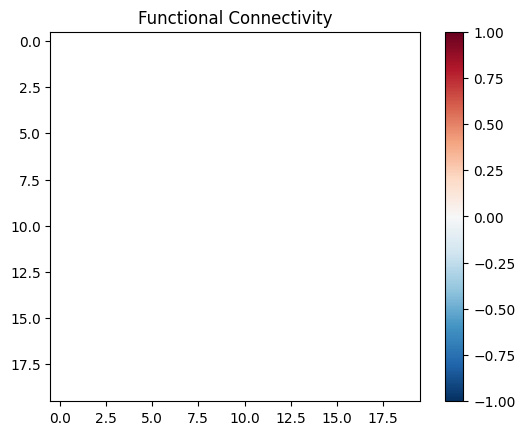

In [11]:
import brainmass
import braintools
import brainstate
import brainunit as u
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

brainstate.environ.set(dt=0.1 * u.ms)
N = 20

# A coupled Hopf network (manual prefetch coupling, as in the quickstart)
nodes = brainmass.HopfStep(in_size=N, a=0.25, w=0.3)
W = np.random.RandomState(0).rand(N, N) * 0.1
np.fill_diagonal(W, 0.0)
W = jnp.asarray(W)

delays = jnp.ones((N, N)) * (1.0 * u.ms)
src_idx = np.tile(np.arange(N)[None, :], (N, 1))
x_delayed = nodes.prefetch_delay('x', delays, src_idx, init=braintools.init.Constant(0.0))
x_local = nodes.prefetch('x')
coupling = brainmass.DiffusiveCoupling(x_delayed, x_local, conn=W, k=0.3)

brainstate.nn.init_all_states(nodes)
brainstate.nn.init_all_states(coupling)

def network_step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        coupling_current = coupling.update()
        nodes.update(coupling_current, 0.0)
        return nodes.x.value

# Simulate the network
activity = brainstate.transform.for_loop(network_step, np.arange(2000))

# Compute FC (Pearson correlation across regions)
activity_centered = activity - activity.mean(axis=0)
FC = jnp.corrcoef(activity_centered.T)   # shape (N, N)

# Visualize
plt.imshow(FC, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Functional Connectivity')
plt.show()

### Network Synchrony

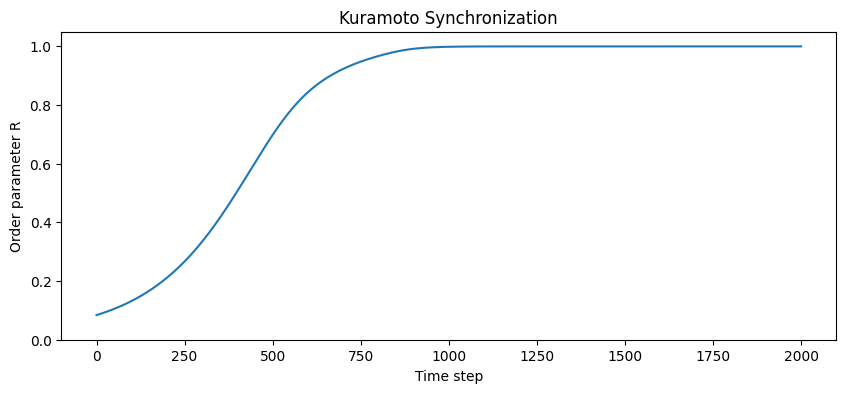

In [12]:
import brainmass
import brainstate
import brainunit as u
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

brainstate.environ.set(dt=0.1 * u.ms)

def kuramoto_order(phases):
    """Global synchronization: R in [0, 1]."""
    z = jnp.mean(jnp.exp(1j * phases), axis=-1)
    return jnp.abs(z)

# A Kuramoto network of phase oscillators with all-to-all-ish coupling
N = 100
conn = np.asarray(np.random.RandomState(0).rand(N, N) * 0.1)
np.fill_diagonal(conn, 0.0)
kuramoto_net = brainmass.KuramotoNetwork(
    in_size=N,
    omega=1.0,          # intrinsic angular frequency (rad/ms)
    K=2.0,              # coupling strength
    conn=jnp.asarray(conn),
)
kuramoto_net.init_all_states()

def step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        kuramoto_net.update()
        return kuramoto_net.theta.value

phases = brainstate.transform.for_loop(step, np.arange(2000))
order_params = kuramoto_order(phases)   # (2000,)

plt.figure(figsize=(10, 4))
plt.plot(order_params)
plt.xlabel('Time step')
plt.ylabel('Order parameter R')
plt.title('Kuramoto Synchronization')
plt.ylim(0, 1.05)
plt.show()

## Complete Network Example

### Whole-Brain Resting-State Simulation

In [13]:
import brainmass
import braintools
import brainstate
import brainunit as u
import numpy as np
import jax.numpy as jnp

# Parameters
N_regions = 90          # AAL90 atlas
coupling_strength = 0.1

# --- structural connectivity (synthetic, row-normalized) ---
# In practice: SC = jnp.asarray(np.load('AAL90_SC_normalized.npy'))
SC = np.asarray(np.random.RandomState(0).rand(N_regions, N_regions) * 0.1)
np.fill_diagonal(SC, 0.0)
SC = SC / SC.sum(axis=1, keepdims=True)   # row normalization
SC = jnp.asarray(SC)

# --- neural stage: Wilson-Cowan network with spontaneous noise ---
brainstate.environ.set(dt=0.1 * u.ms)
nodes = brainmass.WilsonCowanStep(
    in_size=N_regions,
    noise_E=brainmass.OUProcess(in_size=N_regions, sigma=0.1, tau=100. * u.ms),
    noise_I=brainmass.OUProcess(in_size=N_regions, sigma=0.1, tau=100. * u.ms),
)
net = brainmass.Network(
    nodes,
    conn=SC,
    coupled_var='rE',
    k=coupling_strength,
    delay_init=braintools.init.Constant(0.0),
)

print("Running neural simulation...")
sim = brainmass.Simulator(net, dt=0.1 * u.ms)
res = sim.run(500.0 * u.ms, monitors=lambda m: m.node.rE.value)
neural_activity = res['output']           # (5000, 90)
print(f"Neural activity shape: {neural_activity.shape}")

# --- haemodynamic stage: Balloon-Windkessel BOLD (dimensionless dt) ---
print("Generating BOLD signal...")
brainstate.environ.set(dt=0.01)
bold = brainmass.BOLDSignal(in_size=N_regions)
bold.init_all_states()

def sim_bold(z):
    bold.update(z)
    return bold.bold()

bold_ts = brainstate.transform.for_loop(sim_bold, neural_activity)  # (5000, 90)

# Downsample (illustrative) and compute static FC
bold_downsampled = bold_ts[::20]
FC_sim = jnp.corrcoef(bold_downsampled.T)

brainstate.environ.set(dt=0.1 * u.ms)     # restore the time-unit dt
print(f"Simulated FC shape: {FC_sim.shape}")

Running neural simulation...


Neural activity shape: (5000, 90)
Generating BOLD signal...


Simulated FC shape: (90, 90)


## Best Practices

1. **Start Small**: Test with N=10-20 regions before scaling to N=90+
2. **Normalize Connectivity**: Prevent unstable dynamics from unnormalized SC
3. **Monitor Dynamics**: Plot time series to check for explosions/collapse
4. **Use Noise**: Spontaneous fluctuations prevent fixed points
5. **Check Timescales**: Match dt to fastest dynamics in the network
6. **Profile Performance**: Use JAX profiling for large networks

## Common Issues

**Exploding Activity:**

- Reduce coupling strength `k`
- Normalize connectivity matrix
- Check for positive feedback loops

**No Synchronization:**

- Increase coupling strength
- Check connectivity topology
- Ensure sufficient simulation time

**Slow Simulation:**

- Use JIT compilation: `@jax.jit`
- Reduce number of regions for testing
- Use simpler models (Hopf vs Jansen-Rit)

## Next Steps

- {doc}`/howto/custom_coupling` - Advanced coupling mechanisms
- {doc}`/tutorials/05_forward_models` - Map network activity to neuroimaging signals
- {doc}`/tutorials/06_fitting_with_gradients` - Optimize network parameters

## See Also

- {doc}`../reference/coupling` - Coupling API reference
- {doc}`../reference/models` - Node model options
- {doc}`../gallery/index` - Network simulation examples